In [5]:
# 单元格1：导入所有必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 设置中文字体和图形显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
%matplotlib inline

print("✅ 环境准备完成！")

✅ 环境准备完成！


In [6]:
# 单元格2：加载和探索数据
# 加载鸢尾花数据集
iris = load_iris()
print("数据集基本信息：")
print(f"特征名称: {iris.feature_names}")
print(f"目标名称: {iris.target_names}")
print(f"数据形状: {iris.data.shape}")
print(f"标签形状: {iris.target.shape}")

# 创建DataFrame便于分析
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("\n前5行数据：")
print(df.head())

数据集基本信息：
特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
目标名称: ['setosa' 'versicolor' 'virginica']
数据形状: (150, 4)
标签形状: (150,)

前5行数据：
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


C:\Users\tsc\AppData\Local\Temp\ipykernel_16036\168983855.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[iris.feature_names].hist(ax=axes[0,0], alpha=0.7)


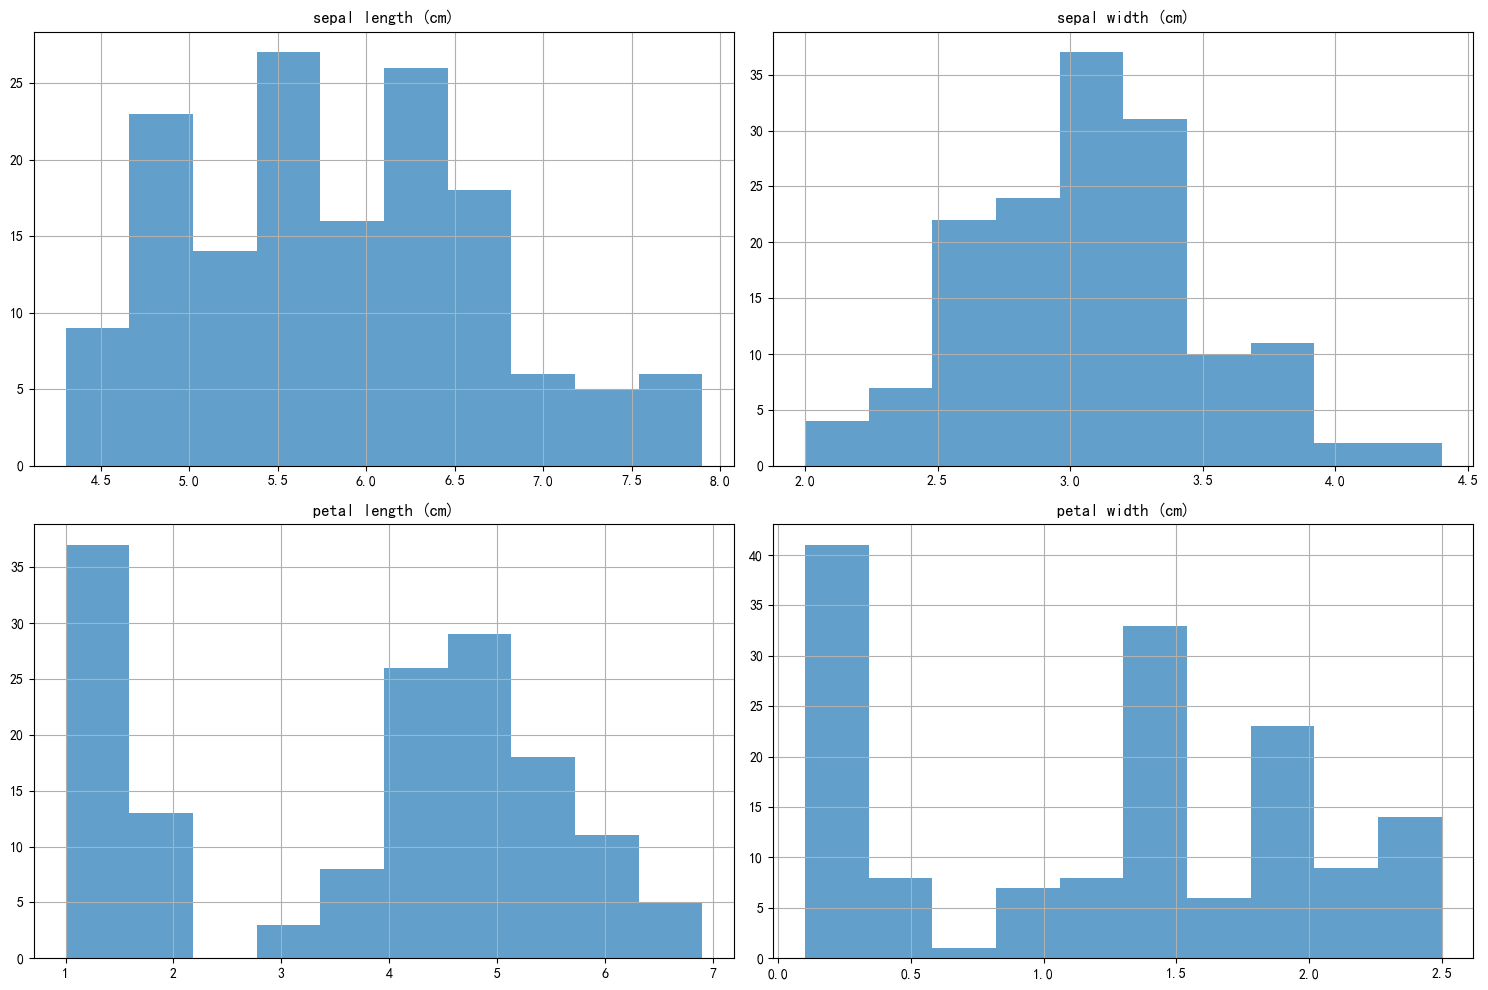

In [7]:
# 单元格3：数据可视化分析
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 特征分布直方图
df[iris.feature_names].hist(ax=axes[0,0], alpha=0.7)
axes[0,0].set_title('特征分布直方图')

# 物种分布饼图
species_counts = df['species_name'].value_counts()
axes[0,1].pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%')
axes[0,1].set_title('物种分布')

# 花萼长度 vs 花萼宽度散点图
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', 
                hue='species_name', ax=axes[1,0])
axes[1,0].set_title('花萼尺寸分布')

# 花瓣长度 vs 花瓣宽度散点图
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', 
                hue='species_name', ax=axes[1,1])
axes[1,1].set_title('花瓣尺寸分布')

plt.tight_layout()
plt.show()

In [8]:
# 单元格4：准备训练数据
X = iris.data  # 特征矩阵
y = iris.target  # 目标标签

print("特征矩阵形状:", X.shape)
print("目标标签形状:", y.shape)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")
print(f"训练集类别分布: {np.bincount(y_train)}")
print(f"测试集类别分布: {np.bincount(y_test)}")

特征矩阵形状: (150, 4)
目标标签形状: (150,)
训练集大小: 120 样本
测试集大小: 30 样本
训练集类别分布: [40 40 40]
测试集类别分布: [10 10 10]


In [9]:
# 单元格5：创建和训练模型
# 创建逻辑回归模型
model = LogisticRegression(
    random_state=42,
    max_iter=1000,  # 增加迭代次数确保收敛
    multi_class='multinomial'  # 多分类问题
)

# 训练模型
model.fit(X_train, y_train)

print("✅ 模型训练完成！")
print(f"模型参数: {model.coef_.shape}")
print(f"模型截距: {model.intercept_.shape}")

✅ 模型训练完成！
模型参数: (3, 4)
模型截距: (3,)


D:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [10]:
# 单元格6：模型预测
# 在测试集上进行预测
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)  # 预测概率

print("前10个样本的预测结果：")
for i in range(10):
    actual = iris.target_names[y_test[i]]
    predicted = iris.target_names[y_pred[i]]
    probabilities = y_pred_proba[i]
    print(f"样本{i+1}: 实际={actual}, 预测={predicted}, 概率={probabilities}")

前10个样本的预测结果：
样本1: 实际=setosa, 预测=setosa, 概率=[9.85317236e-01 1.46827177e-02 4.62323172e-08]
样本2: 实际=virginica, 预测=virginica, 概率=[0.00137652 0.39093866 0.60768482]
样本3: 实际=versicolor, 预测=versicolor, 概率=[0.18689009 0.80890667 0.00420324]
样本4: 实际=versicolor, 预测=versicolor, 概率=[0.1558626  0.83990722 0.00423018]
样本5: 实际=setosa, 预测=setosa, 概率=[9.88257510e-01 1.17424545e-02 3.53992119e-08]
样本6: 实际=versicolor, 预测=versicolor, 概率=[0.00437812 0.68889831 0.30672357]
样本7: 实际=setosa, 预测=setosa, 概率=[9.95163120e-01 4.83687431e-03 5.36534593e-09]
样本8: 实际=setosa, 预测=setosa, 概率=[9.38733922e-01 6.12657730e-02 3.05214219e-07]
样本9: 实际=virginica, 预测=virginica, 概率=[1.99808825e-04 1.71174944e-01 8.28625247e-01]
样本10: 实际=versicolor, 预测=versicolor, 概率=[0.01352938 0.73553744 0.25093318]


模型准确率: 0.9667 (96.67%)

详细分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



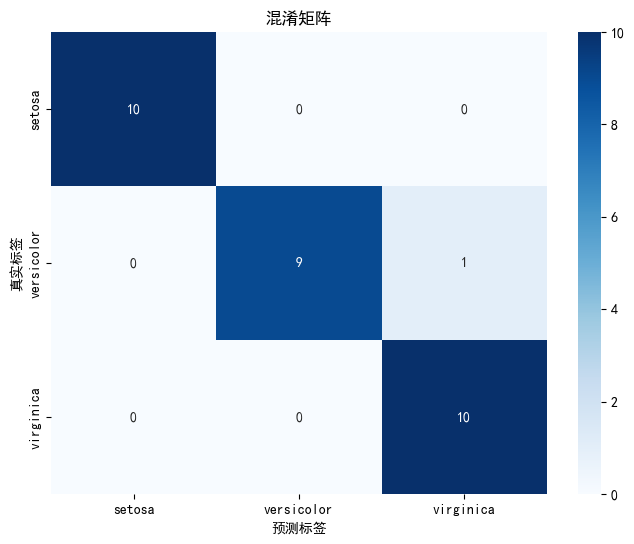

In [11]:
# 单元格7：评估模型性能
# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 详细分类报告
print("\n详细分类报告：")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title('混淆矩阵')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()

In [12]:
# 单元格8：保存模型
import joblib

# 保存训练好的模型
model_filename = 'iris_classifier.pkl'
joblib.dump(model, model_filename)
print(f"✅ 模型已保存为: {model_filename}")

# 保存特征名称（用于后续使用）
feature_names = iris.feature_names
target_names = iris.target_names
joblib.dump({'features': feature_names, 'targets': target_names}, 'iris_metadata.pkl')

✅ 模型已保存为: iris_classifier.pkl


['iris_metadata.pkl']

In [13]:
# 单元格9：加载模型并进行新预测
# 模拟新数据预测
def predict_new_flower(sepal_length, sepal_width, petal_length, petal_width):
    """预测新鸢尾花品种"""
    # 加载模型和元数据
    model = joblib.load('iris_classifier.pkl')
    metadata = joblib.load('iris_metadata.pkl')
    
    # 创建输入数据
    new_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    
    # 进行预测
    prediction = model.predict(new_data)[0]
    probabilities = model.predict_proba(new_data)[0]
    
    # 输出结果
    species = metadata['targets'][prediction]
    confidence = probabilities[prediction]
    
    print(f"预测结果: {species}")
    print(f"置信度: {confidence:.4f} ({confidence*100:.2f}%)")
    print("\n所有类别概率:")
    for i, prob in enumerate(probabilities):
        print(f"  {metadata['targets'][i]}: {prob:.4f}")
    
    return species, confidence

# 测试预测函数
print("测试新数据预测：")
predict_new_flower(5.1, 3.5, 1.4, 0.2)  # 应该是setosa
print("\n" + "="*50)
predict_new_flower(6.7, 3.0, 5.2, 2.3)  # 应该是virginica

测试新数据预测：
预测结果: setosa
置信度: 0.9784 (97.84%)

所有类别概率:
  setosa: 0.9784
  versicolor: 0.0216
  virginica: 0.0000

预测结果: virginica
置信度: 0.9074 (90.74%)

所有类别概率:
  setosa: 0.0001
  versicolor: 0.0925
  virginica: 0.9074


('virginica', 0.9073697732352269)

逻辑回归: 平均准确率 = 0.9733 (±0.0249)
K近邻: 平均准确率 = 0.9733 (±0.0249)
支持向量机: 平均准确率 = 0.9667 (±0.0211)
决策树: 平均准确率 = 0.9533 (±0.0340)
随机森林: 平均准确率 = 0.9667 (±0.0211)


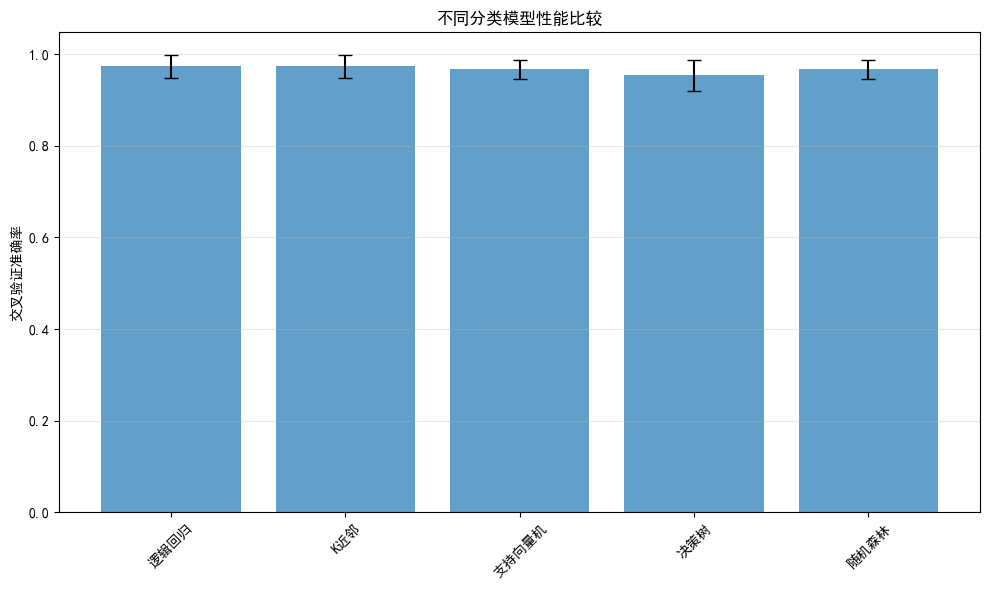

In [14]:
# 单元格10：尝试不同的模型比较
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

models = {
    '逻辑回归': LogisticRegression(random_state=42, max_iter=1000),
    'K近邻': KNeighborsClassifier(),
    '支持向量机': SVC(random_state=42),
    '决策树': DecisionTreeClassifier(random_state=42),
    '随机森林': RandomForestClassifier(random_state=42)
}

# 比较不同模型的性能
results = {}
for name, model in models.items():
    # 使用交叉验证评估
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results[name] = {
        'mean_score': cv_scores.mean(),
        'std_score': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"{name}: 平均准确率 = {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# 可视化比较结果
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
scores = [results[name]['mean_score'] for name in model_names]
errors = [results[name]['std_score'] for name in model_names]

plt.bar(model_names, scores, yerr=errors, capsize=5, alpha=0.7)
plt.title('不同分类模型性能比较')
plt.ylabel('交叉验证准确率')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# 训练完成后，直接使用模型预测
# 单元格11：基础调用演示

# 方法1：直接使用model.predict()
print("=== 方法1：直接调用 ===")
# 输入格式: [花萼长度, 花萼宽度, 花瓣长度, 花瓣宽度]
new_sample = [5.1, 3.5, 1.4, 0.2]  # 注意是列表格式

# 预测类别
predicted_class = model.predict([new_sample])[0]  # 需要双层括号
predicted_species = iris.target_names[predicted_class]

# 预测概率
probabilities = model.predict_proba([new_sample])[0]

print(f"输入数据: {new_sample}")
print(f"预测种类: {predicted_species}")
print(f"置信度: {probabilities[predicted_class]:.2%}")
print(f"所有概率: {dict(zip(iris.target_names, probabilities))}")

=== 方法1：直接调用 ===
输入数据: [5.1, 3.5, 1.4, 0.2]
预测种类: setosa
置信度: 100.00%
所有概率: {'setosa': 1.0, 'versicolor': 0.0, 'virginica': 0.0}


In [18]:
# 单元格12：创建用户友好函数
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    """
    鸢尾花分类预测函数
    
    参数:
    sepal_length (float): 花萼长度 (cm)
    sepal_width (float): 花萼宽度 (cm) 
    petal_length (float): 花瓣长度 (cm)
    petal_width (float): 花瓣宽度 (cm)
    
    返回:
    dict: 包含预测结果的字典
    """
    # 1. 准备输入数据
    input_data = [[sepal_length, sepal_width, petal_length, petal_width]]
    
    # 2. 模型预测
    class_id = model.predict(input_data)[0]
    proba = model.predict_proba(input_data)[0]
    
    # 3. 整理结果
    result = {
        'species': iris.target_names[class_id],
        'class_id': int(class_id),
        'confidence': float(proba[class_id]),
        'probabilities': {
            'setosa': float(proba[0]),
            'versicolor': float(proba[1]), 
            'virginica': float(proba[2])
        },
        'input_features': {
            'sepal_length': sepal_length,
            'sepal_width': sepal_width,
            'petal_length': petal_length, 
            'petal_width': petal_width
        }
    }
    
    return result

# 使用示例
print("=== 方法2：封装函数调用 ===")
result = predict_iris(5.1, 3.5, 1.4, 0.2)
print(f"预测结果: {result['species']}")
print(f"置信度: {result['confidence']:.2%}")
print(f"详细概率: {result['probabilities']}")

=== 方法2：封装函数调用 ===
预测结果: setosa
置信度: 100.00%
详细概率: {'setosa': 1.0, 'versicolor': 0.0, 'virginica': 0.0}


In [20]:
# 单元格13：批量预测多个样本
def predict_iris_batch(samples):
    """
    批量预测函数
    
    参数:
    samples (list): 多个样本的列表，每个样本是[sl, sw, pl, pw]
    
    返回:
    list: 每个样本的预测结果
    """
    predictions = model.predict(samples)
    probabilities = model.predict_proba(samples)
    
    results = []
    for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
        results.append({
            'sample_id': i + 1,
            'species': iris.target_names[pred],
            'confidence': prob[pred],
            'all_probabilities': dict(zip(iris.target_names, prob))
        })
    
    return results

# 批量使用示例
print("=== 方法3：批量预测 ===")
batch_samples = [
    [5.1, 3.5, 1.4, 0.2],  # 样本1
    [6.7, 3.0, 5.2, 2.3],  # 样本2
    [5.9, 3.0, 4.2, 1.5],  # 样本3
    [6.3, 2.5, 4.9, 1.5]   # 样本4
]

batch_results = predict_iris_batch(batch_samples)
for result in batch_results:
    print(f"样本{result['sample_id']}: {result['species']} (置信度: {result['confidence']:.2%})")

=== 方法3：批量预测 ===
样本1: setosa (置信度: 100.00%)
样本2: virginica (置信度: 100.00%)
样本3: versicolor (置信度: 98.00%)
样本4: versicolor (置信度: 83.00%)


In [24]:
# 单元格14：交互式预测
def interactive_prediction():
    """
    交互式预测函数 - 从用户输入获取数据
    """
    print("🌺 鸢尾花分类器")
    print("请输入花的测量数据 (单位: cm)")
    print("-" * 40)
    
    try:
        # 获取用户输入
        sl = float(input("花萼长度: "))
        sw = float(input("花萼宽度: "))
        pl = float(input("花瓣长度: "))
        pw = float(input("花瓣宽度: "))
        
        # 调用预测函数
        result = predict_iris(sl, sw, pl, pw)
        
        # 显示结果
        print("\n" + "="*40)
        print(f"📊 预测结果: {result['species']}")
        print(f"✅ 置信度: {result['confidence']:.2%}")
        print("\n详细概率分布:")
        for species, prob in result['probabilities'].items():
            print(f"  {species}: {prob:.2%}")
            
    except ValueError:
        print("❌ 错误: 请输入有效的数字！")
    except Exception as e:
        print(f"❌ 错误: {e}")

# 运行交互式预测
print("=== 方法4：交互式调用 ===")
interactive_prediction()

=== 方法4：交互式调用 ===
🌺 鸢尾花分类器
请输入花的测量数据 (单位: cm)
----------------------------------------


花萼长度:  6
花萼宽度:  5
花瓣长度:  4
花瓣宽度:  4



📊 预测结果: versicolor
✅ 置信度: 59.00%

详细概率分布:
  setosa: 2.00%
  versicolor: 59.00%
  virginica: 39.00%


In [22]:
# 单元格15：从文件预测
import pandas as pd

def predict_from_csv(file_path):
    """
    从CSV文件读取数据并进行预测
    
    参数:
    file_path (str): CSV文件路径
    """
    # 读取数据
    df = pd.read_csv(file_path)
    print(f"读取到 {len(df)} 个样本")
    
    # 检查列名（确保有需要的特征列）
    required_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
    
    for col in required_columns:
        if col not in df.columns:
            print(f"❌ 错误: 缺少列 '{col}'")
            return
    
    # 准备特征数据
    features = df[required_columns].values
    
    # 批量预测
    results = predict_iris_batch(features)
    
    # 显示结果
    print("\n预测结果:")
    print("-" * 50)
    for i, (idx, row) in enumerate(df.iterrows()):
        result = results[i]
        print(f"样本{idx+1}: {result['species']} (置信度: {result['confidence']:.2%})")
        print(f"  特征: {row[required_columns].tolist()}")
    
    # 保存结果到新文件
    result_df = df.copy()
    result_df['predicted_species'] = [r['species'] for r in results]
    result_df['confidence'] = [r['confidence'] for r in results]
    
    output_path = 'prediction_results.csv'
    result_df.to_csv(output_path, index=False)
    print(f"\n✅ 预测结果已保存到: {output_path}")

# 创建示例CSV文件进行测试
sample_data = {
    'sepal_length': [5.1, 6.7, 5.9],
    'sepal_width': [3.5, 3.0, 3.0],
    'petal_length': [1.4, 5.2, 4.2],
    'petal_width': [0.2, 2.3, 1.5]
}

sample_df = pd.DataFrame(sample_data)
sample_df.to_csv('test_samples.csv', index=False)

print("=== 方法5：文件批量预测 ===")
predict_from_csv('test_samples.csv')

=== 方法5：文件批量预测 ===
读取到 3 个样本

预测结果:
--------------------------------------------------
样本1: setosa (置信度: 100.00%)
  特征: [5.1, 3.5, 1.4, 0.2]
样本2: virginica (置信度: 100.00%)
  特征: [6.7, 3.0, 5.2, 2.3]
样本3: versicolor (置信度: 98.00%)
  特征: [5.9, 3.0, 4.2, 1.5]

✅ 预测结果已保存到: prediction_results.csv
